## 4.1

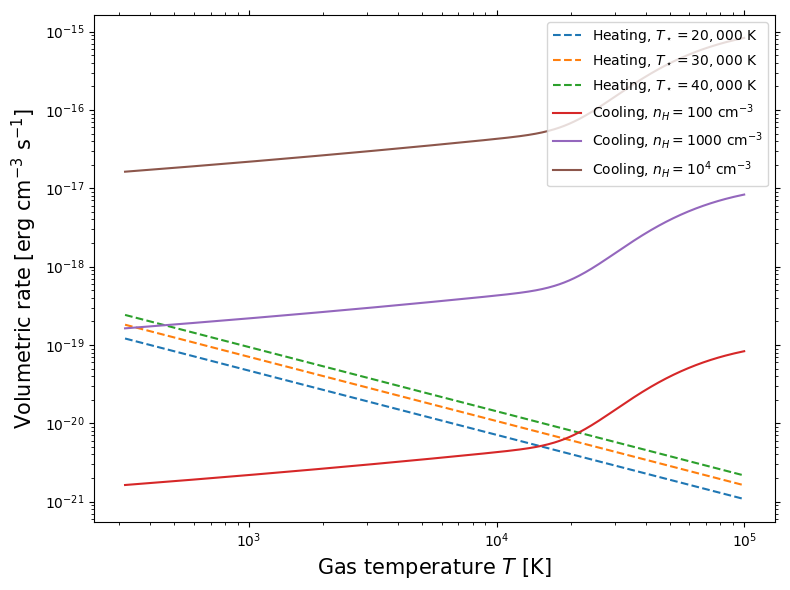

In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as cst

x = 0.9996 # Ionization fraction in HII

def cooling_rr(T,n_H):
    alpha_B = 3.1e-13 * (T / 8000.)**(-0.82)  # cm^3 s^-1
    E_rr = 0.68 * cst.k_B.cgs.value * T         # erg
    return (x**2) * n_H**2 * alpha_B * E_rr

def cooling_ff(T,n_H):
    g_ff = 1.3
    Lambda_ff_0 = ((32. * np.pi / 3.)* np.sqrt(2. * np.pi / 3.)* cst.e.esu.value**6/(cst.h.cgs.value* cst.m_e.cgs.value* cst.c.cgs.value**2))
    return (g_ff * Lambda_ff_0 * np.sqrt(cst.k_B.cgs.value*T/(cst.m_e.cgs.value * cst.c.cgs.value**2))*(x*n_H)**2)

def cooling_Lya(T,n_H):
    return x*(1-x)*n_H**2*6E5*(x/1E-3)*(T/1000)**(-0.5)*np.exp(-1.18E5/T)*(1E-27)

def cooling_total(T,n_H):
    """T in K, n_H in cm^-3"""
    return cooling_rr(T,n_H) + cooling_ff(T,n_H) + cooling_Lya(T,n_H)

def heating_photoionization(T, T_star, n_H):
    alpha_B = 3.1e-13 * (T / 8000.)**(-0.82)
    return x**2*n_H**2 * alpha_B * cst.k_B.cgs.value * T_star

fig = plt.figure(figsize=(8,6))
ax = plt.subplot(111)
T = np.logspace(2.5, 5.0, 500)
ax.plot(T, heating_photoionization(T, 2e4, 100), ls='--', label=r'Heating, $T_\star=20,000$ K')
ax.plot(T, heating_photoionization(T, 3e4, 100), ls='--', label=r'Heating, $T_\star=30,000$ K')
ax.plot(T, heating_photoionization(T, 4e4, 100), ls='--', label=r'Heating, $T_\star=40,000$ K')

ax.plot(T, cooling_total(T, 100), label=r'Cooling, $n_H=100$ cm$^{-3}$')
ax.plot(T, cooling_total(T, 1000), label=r'Cooling, $n_H=1000$ cm$^{-3}$')
ax.plot(T, cooling_total(T, 1e4), label=r'Cooling, $n_H=10^4$ cm$^{-3}$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Gas temperature $T$ [K]',fontsize=15)
ax.set_ylabel(r'Volumetric rate [erg cm$^{-3}$ s$^{-1}$]',fontsize=15)
ax.legend()
ax.tick_params(which='both', top=True, right=True)
plt.tight_layout()
plt.savefig("3_3.pdf", bbox_inches="tight")
plt.show()


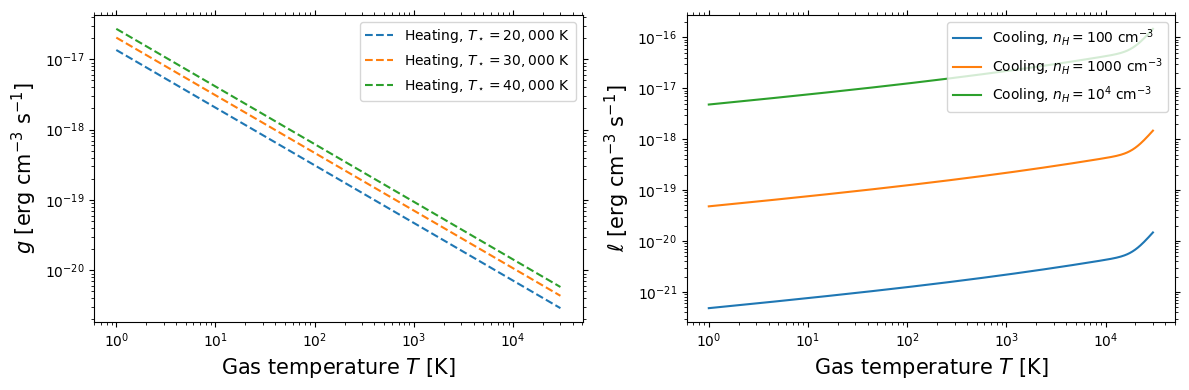

In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as cst

x = 0.9996 # Ionization fraction in HII

def cooling_rr(T,n_H):
    alpha_B = 3.1e-13 * (T / (8000*u.K))**(-0.82)*u.cm**3*u.s**-1
    return ((x*n_H)**2 * alpha_B * 0.68*cst.k_B*T).to(u.erg*u.cm**-3*u.s**-1)


def cooling_ff(T,n_H):
    Lambda_0 = 32*np.pi/(3)*np.sqrt(2*np.pi/3)*cst.e.esu**6/(cst.h*cst.m_e*cst.c**2)*np.sqrt(cst.k_B*T/(cst.m_e*cst.c**2))
    return (1.3*Lambda_0*(x*n_H)**2).to(u.erg*u.cm**-3*u.s**-1)
    
def cooling_Lya(T,n_H):
    return (6E5*(x/1E-3)*x*(1-x)*(n_H)**2*(T/(1000*u.K))**(-0.5)*np.exp(-1.18E5*u.K/T)*1E-27*u.erg*u.cm**3*u.s**-1).to(u.erg*u.cm**-3*u.s**-1)

def cooling_total(T,n_H):
    """T in K, n_H in cm^-3"""
    return cooling_rr(T,n_H) + cooling_ff(T,n_H) + cooling_Lya(T,n_H)

def heating_photoionization(T, T_star, n_H):
    alpha_B = 3.1e-13 * (T / (8000*u.K))**(-0.82)*u.cm**3*u.s**-1
    return (x**2*n_H**2 * alpha_B * cst.k_B * T_star).to(u.erg*u.cm**-3*u.s**-1)

fig = plt.figure(figsize=(12,4))
ax = plt.subplot(121)
ax2 = plt.subplot(122)
T = np.logspace(0, np.log10(30000), 500)*u.K

ax.plot(T, heating_photoionization(T, 2e4*u.K, 100*(u.cm**-3)), ls='--', label=r'Heating, $T_\star=20,000$ K')
ax.plot(T, heating_photoionization(T, 3e4*u.K, 100*(u.cm**-3)), ls='--', label=r'Heating, $T_\star=30,000$ K')
ax.plot(T, heating_photoionization(T, 4e4*u.K, 100*(u.cm**-3)), ls='--', label=r'Heating, $T_\star=40,000$ K')

ax2.plot(T, cooling_total(T, 100*(u.cm**-3)), label=r'Cooling, $n_H=100$ cm$^{-3}$')
ax2.plot(T, cooling_total(T, 1000*(u.cm**-3)), label=r'Cooling, $n_H=1000$ cm$^{-3}$')
ax2.plot(T, cooling_total(T, 1e4*(u.cm**-3)), label=r'Cooling, $n_H=10^4$ cm$^{-3}$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'Gas temperature $T$ [K]',fontsize=15)
ax.set_ylabel(r'$g$ [erg cm$^{-3}$ s$^{-1}$]',fontsize=15)
ax.legend()
ax.tick_params(which='both', top=True, right=True)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'Gas temperature $T$ [K]',fontsize=15)
ax2.set_ylabel(r'$\ell$ [erg cm$^{-3}$ s$^{-1}$]',fontsize=15)
ax2.legend()
ax2.tick_params(which='both', top=True, right=True)
plt.tight_layout()
plt.savefig("3_3.pdf", bbox_inches="tight")
plt.show()


C:\Users\olivi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\astropy\units\quantity.py:648: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
C:\Users\olivi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\astropy\units\quantity.py:648: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
C:\Users\olivi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\astropy\units\quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


20000.0 14995.544233340062
30000.0 18908.642707218816
40000.0 21467.62757727894


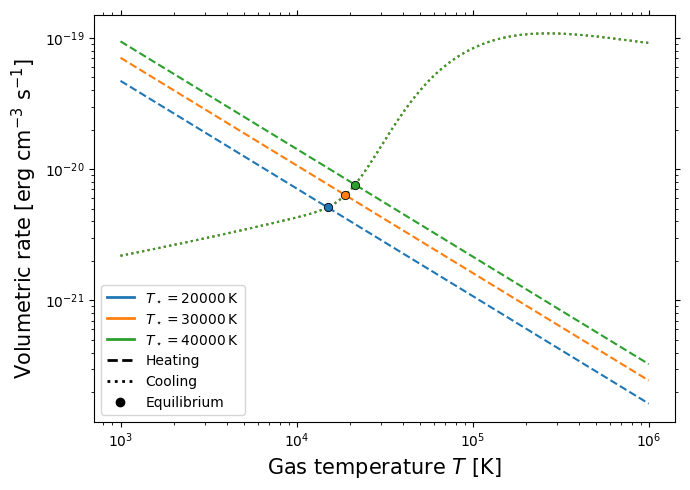

In [18]:
from scipy.optimize import minimize_scalar
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 5))
T = np.logspace(3, 6, 500) * u.K

t_stars = [2E4,3E4,4E4]
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
rate_unit = u.erg / (u.cm**3 * u.s)
n_H = 100 * u.cm**-3

for t_star, color in zip(t_stars, colors):

    heating = heating_photoionization(T, t_star * u.K, n_H)
    cooling = cooling_total(T, n_H)

    ax.plot(T, heating, color=color, ls="--")
    ax.plot(T, cooling, color=color, ls=":")

    def balance(T):
        return ((heating_photoionization(T*u.K, t_star * u.K, n_H) - cooling_total(T*u.K, n_H)).to_value(rate_unit))**2
    res = minimize_scalar(balance)
    T_eq, rate_eq = res.x, cooling_total(res.x*u.K, n_H)
    print(t_star, T_eq)
    ax.plot(T_eq, rate_eq,marker="o", ms=6, color=color,markeredgecolor="black", markeredgewidth=0.6,linestyle="none", zorder=5,)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Gas temperature $T$ [K]", fontsize=15)
ax.set_ylabel(r"Volumetric rate [erg cm$^{-3}$ s$^{-1}$]", fontsize=15)
ax.tick_params(which="both", top=True, right=True)

density_handles = [
    Line2D([0], [0], color=color, lw=2,
           label=rf"$T_\star={t_star:g}\,\mathrm{{K}}$")
    for t_star, color in zip(t_stars, colors)
]
style_handles = [
    Line2D([0], [0], color="black", ls="--", lw=2, label="Heating"),
    Line2D([0], [0], color="black", ls=":", lw=2, label="Cooling"),
    Line2D([0], [0], marker="o", color="black", linestyle="none",
           label="Equilibrium"),
]

ax.legend(handles=density_handles + style_handles)
plt.tight_layout()
plt.savefig("3_4.pdf", bbox_inches="tight")
plt.show()

C:\Users\olivi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\astropy\units\quantity.py:648: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
C:\Users\olivi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\astropy\units\quantity.py:648: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
C:\Users\olivi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\astropy\units\quantity.py:648: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


100 18908.642707218816
1000 18908.64270721882
10000.0 18908.642707218816


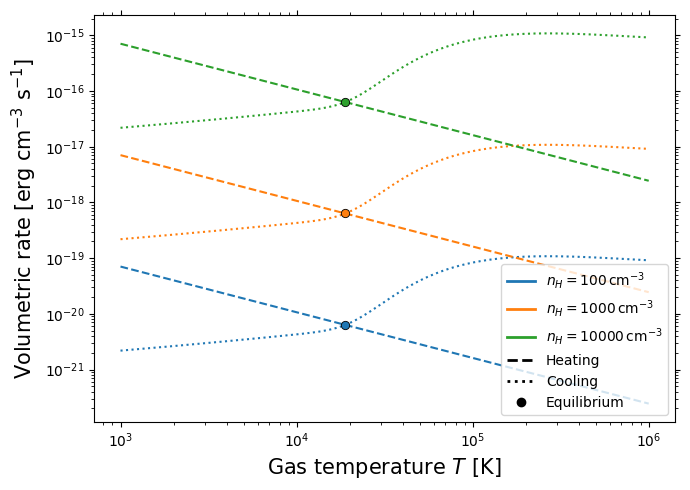

In [19]:
from scipy.optimize import brentq
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(7, 5))
T = np.logspace(3, 6, 500) * u.K

densities = [100, 1000, 1e4]
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
rate_unit = u.erg / (u.cm**3 * u.s)
t_star = 3E4

for n, color in zip(densities, colors):
    n_H = n * u.cm**-3

    heating = heating_photoionization(T, 3e4 * u.K, n_H)
    cooling = cooling_total(T, n_H)

    ax.plot(T, heating, color=color, ls="--")
    ax.plot(T, cooling, color=color, ls=":")

    # Find all heating/cooling crossings over the plotted temperature range.
    def balance(T):
        return ((heating_photoionization(T*u.K, t_star * u.K, n_H) - cooling_total(T*u.K, n_H)).to_value(rate_unit))**2
    res = minimize_scalar(balance)
    T_eq, rate_eq = res.x, cooling_total(res.x*u.K, n_H)
    print(n, T_eq)
    ax.plot(T_eq, rate_eq,marker="o", ms=6, color=color,markeredgecolor="black", markeredgewidth=0.6,linestyle="none", zorder=5,)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Gas temperature $T$ [K]", fontsize=15)
ax.set_ylabel(r"Volumetric rate [erg cm$^{-3}$ s$^{-1}$]", fontsize=15)
ax.tick_params(which="both", top=True, right=True)

density_handles = [
    Line2D([0], [0], color=color, lw=2,
           label=rf"$n_H={n:g}\,\mathrm{{cm}}^{{-3}}$")
    for n, color in zip(densities, colors)
]
style_handles = [
    Line2D([0], [0], color="black", ls="--", lw=2, label="Heating"),
    Line2D([0], [0], color="black", ls=":", lw=2, label="Cooling"),
    Line2D([0], [0], marker="o", color="black", linestyle="none",
           label="Equilibrium"),
]

ax.legend(handles=density_handles + style_handles)
plt.tight_layout()
plt.savefig("3_5.pdf", bbox_inches="tight")
plt.show()